In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
my_cols = ["red", "darkorange", "gold", "limegreen","dodgerblue", "deepppink", "darkpurple"]

In [51]:
def clean_data(df, failed_image_names):
    df= df[df["flag"]!="IMAGE FAILED"]
    # build combined key
    combined = df["lif_name"].astype(str) + "_" + df["image_name"].astype(str)
    # keep only rows NOT in failed_image_names
    df = df[~combined.isin(failed_image_names)]    
    df = df[df["final_gel_intensity"]!=0.0]
    df = df.drop(["Unnamed: 0", "flag"], axis=1)
    def helper(row):
        lif_name = str(row['lif_name']).lower()
        image_name = str(row['image_name']).lower()
        row["position"] = image_name.split("/")[-1].replace(" ", "")
        row["device"] = image_name.split("_")[-1].split("/")[0]
        row['sample'] = image_name.split("_")[0]
        row["milestone"] = lif_name.split("_")[0]
        row["date"]= lif_name.split("_")[1]
        if "rln" in row['sample']:
            row['condition'] = 'rln'
        elif "bead" in row['sample']:
            row['condition'] = 'bead'
        elif "fl" in row["sample"]:
            row['condition'] = 'fl'
        elif "mcl" in row["sample"]:
            row["condition"] = "mcl"
        else:
            row["condition"] = "unknown"
        if 'lpos' in lif_name or "ligpos" in image_name:
            row['ligand'] = 'Positive'
        elif 'lneg' in lif_name or "ligneg" in image_name:
            row['ligand'] = 'False'
        else:
            row["ligand"] = "unknown"
        return row
    df =  df.apply(helper, axis=1)
    first = ["milestone", "date", "sample", "device", "position" ,"p_cm/s", "p_um/s", "condition"]

    df = df[first + [c for c in df.columns if c not in first]]
    return df

In [71]:
folder = Path(r"C:/Users/taylorhearn/git_repos/image_quantification/Vasculature/outputs")
csv_files = list(folder.glob("*.csv"))
print(len(csv_files))


11


In [72]:
all_csvs = []
for csv_file in csv_files:
    csv = pd.read_csv(csv_file)
    all_csvs.append(csv)
    

In [73]:
all_data = pd.concat(all_csvs)

In [74]:
failed_image_names = ["m7_2025.12.04_fl39__Bead_dev3/P 2"]
all_data=clean_data(all_data, failed_image_names)

In [75]:
all_data

,milestone,date,sample,device,position,p_cm/s,p_um/s,condition,lif_name,image_name,image_shape,final_gel_intensity,final_vascular_intensity,initial_gel_intensity,initial_vascular_intensity,vascular_volume_um3,gel_volume_um3,vasculature_surface_area_um2,bleaching_coefficient,ligand
0,m4,2024.10.24,rln2,device1,p2,3.445425e-07,0.003445,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 2,"(3, 36, 512, 512)",15246285.0,116276721.0,11906772.0,124558040.0,7.342314e+07,1.704046e+08,5.396960e+06,1.071221,unknown
1,m4,2024.10.24,rln2,device1,p1,3.821311e-07,0.003821,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 1,"(3, 42, 512, 512)",17222645.0,88108795.0,14422564.0,91270589.0,7.262491e+07,2.113264e+08,6.832713e+06,1.035885,unknown
2,m4,2024.10.24,rln2,device1,p4,2.036221e-07,0.002036,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 4,"(3, 41, 512, 512)",15005195.0,114410632.0,13182857.0,119022366.0,7.678528e+07,2.009932e+08,6.287928e+06,1.040309,unknown
3,m4,2024.10.24,rln2,device1,p3,8.590670e-08,0.000859,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 3,"(3, 42, 512, 512)",18832157.0,134287948.0,18135117.0,139589283.0,9.163753e+07,1.923138e+08,7.375254e+06,1.039477,unknown
5,m4,2024.10.24,fl2,device1,p1,9.586856e-07,0.009587,fl,m4_2024.10.24_fl2_fl6,FL2_24.10.24_device1/P 1,"(3, 39, 512, 512)",51458024.0,115178690.0,31348719.0,110135419.0,9.560956e+07,1.698232e+08,1.115201e+07,0.956214,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,m7,2025.12.04,fl39,dev6,p3,2.620373e-07,0.002620,fl,m7_2025.12.04_fl39,FL39_LigNeg_dev6/P 3,"(3, 23, 512, 512)",4267082.0,37288975.0,3404380.0,34095623.0,2.594389e+07,1.314639e+08,2.258008e+06,0.914362,False
109,m7,2025.12.04,fl39,dev6,p1,1.538453e-07,0.001538,fl,m7_2025.12.04_fl39,FL39_LigPos_dev6/P 1,"(3, 23, 512, 512)",9094160.0,93709625.0,7980687.0,92497613.0,4.116017e+07,1.162476e+08,2.473139e+06,0.987066,Positive
110,m7,2025.12.04,fl39,dev6,p2,3.928440e-08,0.000393,fl,m7_2025.12.04_fl39,FL39_LigPos_dev6/P 2,"(3, 23, 512, 512)",7043379.0,91546997.0,9198311.0,125115270.0,5.541774e+07,1.019901e+08,2.661021e+06,1.366678,Positive
111,m7,2025.12.04,fl39,dev6,p4,3.227966e-08,0.000323,fl,m7_2025.12.04_fl39,FL39_LigPos_dev6/P 4,"(3, 16, 512, 512)",5217697.0,88274753.0,5180061.0,91979020.0,3.845379e+07,6.957118e+07,1.769767e+06,1.041963,Positive


In [76]:
all_data.to_csv("./outputs/combined_outputs.csv")


Text(0.5, 0, 'Permeability cm/s')

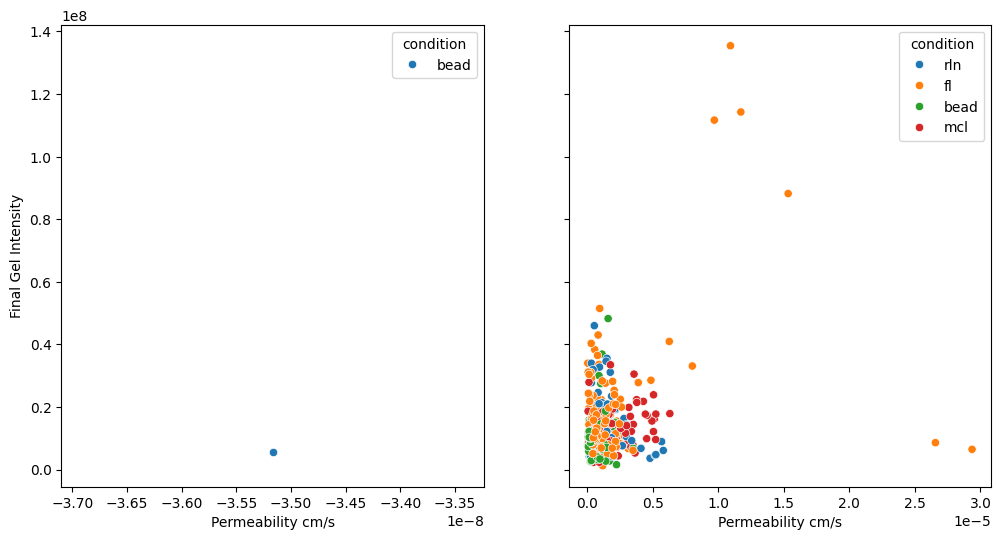

In [26]:
m4 = all_data[all_data["milestone"]=="m4"]
m4 = m4[m4["condition"]!="unknown"]
neg_data = m4[m4["p_cm/s"]<0]
pos_data = m4[m4["p_cm/s"]>=0]
fig, ax = plt.subplots(ncols=2, figsize=(12, 6), sharey=True)
sns.scatterplot(data=neg_data, y="final_gel_intensity", x="p_cm/s",  ax=ax[0], hue = "condition")
sns.scatterplot(data=pos_data, y="final_gel_intensity", x="p_cm/s", ax=ax[1],  hue = "condition")
ax[0].set_ylabel("Final Gel Intensity")
ax[0].set_xlabel("Permeability cm/s")
ax[1].set_xlabel("Permeability cm/s")

Text(0.5, 0, 'Permeability cm/s')

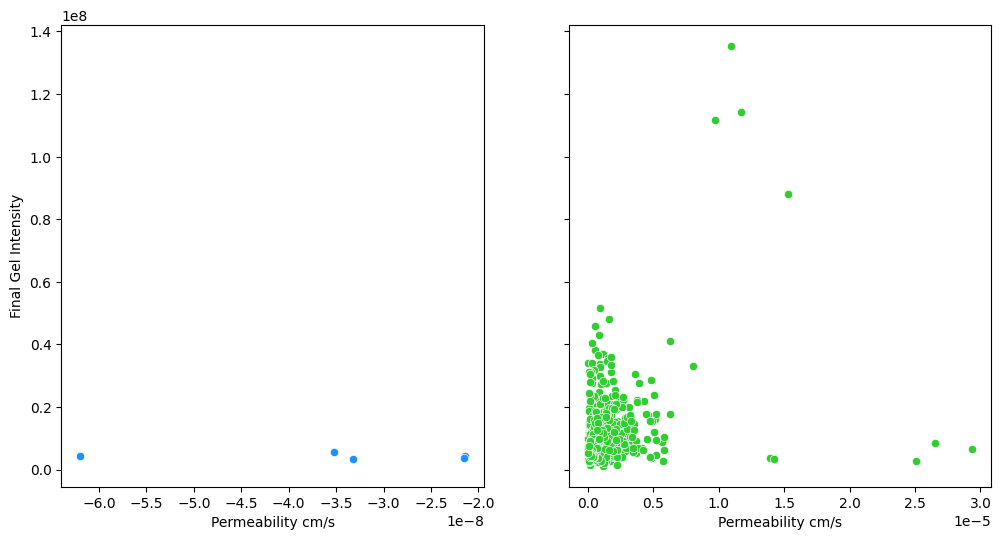

In [ ]:
neg_data = all_data[all_data["p_cm/s"]<0]
pos_data = all_data[all_data["p_cm/s"]>=0]
fig, ax = plt.subplots(ncols=2, figsize=(12, 6), sharey=True)
sns.scatterplot(data=neg_data, y="final_gel_intensity", x="p_cm/s",  ax=ax[0], color="dodgerblue")
sns.scatterplot(data=pos_data, y="final_gel_intensity", x="p_cm/s", ax=ax[1], color="limegreen")
ax[0].set_ylabel("Final Gel Intensity")
ax[0].set_xlabel("Permeability cm/s")
ax[1].set_xlabel("Permeability cm/s")

In [78]:
all_data.head()

,milestone,date,sample,device,position,p_cm/s,p_um/s,condition,lif_name,image_name,image_shape,final_gel_intensity,final_vascular_intensity,initial_gel_intensity,initial_vascular_intensity,vascular_volume_um3,gel_volume_um3,vasculature_surface_area_um2,bleaching_coefficient,ligand
0,m4,2024.10.24,rln2,device1,p2,3.445425e-07,0.003445,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 2,"(3, 36, 512, 512)",15246285.0,116276721.0,11906772.0,124558040.0,7.342314e+07,1.704046e+08,5.396960e+06,1.071221,unknown
1,m4,2024.10.24,rln2,device1,p1,3.821311e-07,0.003821,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 1,"(3, 42, 512, 512)",17222645.0,88108795.0,14422564.0,91270589.0,7.262491e+07,2.113264e+08,6.832713e+06,1.035885,unknown
2,m4,2024.10.24,rln2,device1,p4,2.036221e-07,0.002036,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 4,"(3, 41, 512, 512)",15005195.0,114410632.0,13182857.0,119022366.0,7.678528e+07,2.009932e+08,6.287928e+06,1.040309,unknown
3,m4,2024.10.24,rln2,device1,p3,8.590670e-08,0.000859,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 3,"(3, 42, 512, 512)",18832157.0,134287948.0,18135117.0,139589283.0,9.163753e+07,1.923138e+08,7.375254e+06,1.039477,unknown
5,m4,2024.10.24,fl2,device1,p1,9.586856e-07,0.009587,fl,m4_2024.10.24_fl2_fl6,FL2_24.10.24_device1/P 1,"(3, 39, 512, 512)",51458024.0,115178690.0,31348719.0,110135419.0,9.560956e+07,1.698232e+08,1.115201e+07,0.956214,unknown


In [79]:
OUT_DIR = Path("./outputs./subsets")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# tweak these thresholds
COEFFVAR_FLAG_THRESHOLD = 0.30   # coefficient of variation (std/mean)
STD_FLAG_THRESHOLD = None  # or set e.g. 0.5 to flag by absolute std instead

for date in all_data["date"].unique():
    for milestone in all_data.loc[all_data["date"] == date, "milestone"].unique():

        subset = all_data[
            (all_data["date"] == date) &
            (all_data["milestone"] == milestone)
        ][["sample", "device", "position", "p_cm/s"]].copy()

        # Ensure numeric
        subset["p_cm/s"] = pd.to_numeric(subset["p_cm/s"], errors="coerce")

        # --- summary: average over positions within (condition, device) ---
        summary = (
            subset
            .groupby(["sample", "device"], as_index=False)
            .agg(
                n_positions=("p_cm/s", "count"),
                mean_p=("p_cm/s", "mean"),
                std_p=("p_cm/s", "std"),
            )
        )

        # coefficient of variation (guard against divide-by-zero)
        summary["cv_p"] = summary["std_p"] / summary["mean_p"].replace(0, np.nan)

        # flag high variance
        if STD_FLAG_THRESHOLD is not None:
            summary["high_variance_flag"] = summary["std_p"] > STD_FLAG_THRESHOLD
        else:
            summary["high_variance_flag"] = summary["cv_p"] > COEFFVAR_FLAG_THRESHOLD

        # optional: nicer column name
        summary = summary.rename(columns={"mean_p": "avg_p_cm/s"})

        # --- write one CSV with raw + summary appended ---
        safe_date = str(date).replace("/", "-").replace(":", "-").replace(" ", "_")
        safe_milestone = str(milestone).replace("/", "-").replace(":", "-").replace(" ", "_")
        out_path = OUT_DIR / f"{safe_date}__{safe_milestone}.csv"

        with open(out_path, "w", newline="") as f:
            f.write(f"# date={date}, milestone={milestone}\n")
            f.write("# raw_rows\n")
            subset.to_csv(f, index=False)

            f.write("\n")
            f.write("# summary_by_condition_device\n")
            summary.to_csv(f, index=False)

        print("Saved:", out_path)


Saved: outputs.\subsets\2024.10.24__m4.csv
Saved: outputs.\subsets\2024.11.14__m4.csv
Saved: outputs.\subsets\2024.12.04__m4.csv
Saved: outputs.\subsets\2025.02.05__m4.csv
Saved: outputs.\subsets\2025.02.27__m4.csv
Saved: outputs.\subsets\2025.03.20__m4.csv
Saved: outputs.\subsets\2025.06.27__m4.csv
Saved: outputs.\subsets\2025.10.02__m7.csv
Saved: outputs.\subsets\2025.10.22__m7.csv
Saved: outputs.\subsets\2025.11.12__m7.csv
Saved: outputs.\subsets\2025.12.04__m7.csv


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
test = pd.read_csv(r"c:\Users\taylorhearn\Downloads\perfusion_all_images.csv")

In [19]:
test = test[test["p_cm/s"] > 0]
test.head()

,lif_name,image_name,dextran_channel,dextran_channel_index,image_shape,final_gel_intensity,final_vascular_intensity,initial_gel_intensity,initial_vascular_intensity,vascular_volume_um3,gel_volume_um3,vasculature_surface_area_um2,bleaching_coefficient,p_um/s,p_cm/s,flag
0,seedingmifcellswithe2p4_120226,Device1_untreated/P 1,Red,2.0,"(3, 16, 512, 512)",5944778.0,46510984.0,3263702.0,53188817.0,4.031444e+07,6.771053e+07,2.391090e+06,1.143575,0.005569,5.569023e-07,NaN
2,seedingmifcellswithe2p4_120226,Device1_untreated/P 1,Blue,0.0,"(3, 16, 512, 512)",13481885.0,80278428.0,8814208.0,102720623.0,4.031444e+07,6.771053e+07,2.391090e+06,1.279554,0.007067,7.066916e-07,NaN
3,seedingmifcellswithe2p4_120226,Device1_untreated/P 2,Red,2.0,"(3, 13, 512, 512)",11203071.0,77079496.0,6823049.0,88027979.0,3.965679e+07,4.984961e+07,2.284545e+06,1.142041,0.004457,4.457051e-07,NaN
4,seedingmifcellswithe2p4_120226,Device1_untreated/P 2,Yellow,1.0,"(3, 13, 512, 512)",46272405.0,53923706.0,40670740.0,51696525.0,3.965679e+07,4.984961e+07,2.284545e+06,0.958698,0.020288,2.028782e-06,NaN
5,seedingmifcellswithe2p4_120226,Device1_untreated/P 2,Blue,0.0,"(3, 13, 512, 512)",20125589.0,120682159.0,11885010.0,125354317.0,3.965679e+07,4.984961e+07,2.284545e+06,1.038715,0.004818,4.818088e-07,NaN


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_40608\182156134.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test, x="dextran_channel", y="p_cm/s", ax=ax[0], showfliers=False, palette = ["red",  "dodgerblue", "gold"], order=channel_order)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_40608\182156134.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test, x="dextran_channel", y="p_cm/s", ax=ax[1], showfliers=False, palette = ["red",  "dodgerblue", "gold"], order=channel_order)


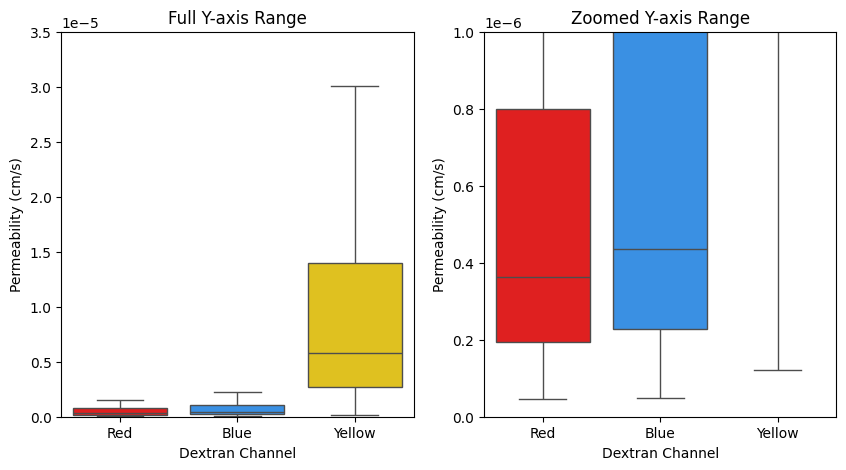

In [29]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))
channel_order = ["Red", "Blue", "Yellow"]

sns.boxplot(data=test, x="dextran_channel", y="p_cm/s", ax=ax[0], showfliers=False, palette = ["red",  "dodgerblue", "gold"], order=channel_order)
ax[0].set_ylabel("Permeability (cm/s)")
ax[0].set_ylim(0, 0.000035)
ax[0].set_title("Full Y-axis Range")
ax[0].set_xlabel("Dextran Channel")
sns.boxplot(data=test, x="dextran_channel", y="p_cm/s", ax=ax[1], showfliers=False, palette = ["red",  "dodgerblue", "gold"], order=channel_order)
ax[1].set_ylabel("Permeability (cm/s)")
ax[1].set_ylim(0, 0.0000010)
ax[1].set_title("Zoomed Y-axis Range")
ax[1].set_xlabel("Dextran Channel")
plt.savefig(r"c:\Users\taylorhearn\Downloads\defne_results.pdf", transparent=True, bbox_inches="tight")